# Cora Dataset Analysis

## Objective

This project investigates the structural properties of the **Cora citation network** through five guiding research questions:

1. Is academic knowledge distributed democratically, or dominated by a small number of influential works?
2. How do milestone papers compare to literature reviews in terms of their network behavior?
3. Does scientific progress occur within isolated disciplinary communities, or through cross-disciplinary interactions?
4. If the network is composed of segregated communities, what mechanisms enable global information flow?
5. What happens when a novel idea is introduced into the network?

The goal is to address these questions through a systematic analysis of the Cora dataset and its underlying graph structure.

## Network Setup
We begin by configuring the network environment for the analysis. This includes importing all the required libraries used throughout the project, loading the Cora dataset, and constructing the corresponding directed graph representation.

In [93]:
# STANDARD PYTHON LIBRARIES (Built-in)
import collections
import http.server
import json
import socketserver
import threading
import webbrowser
from collections import Counter

# PLOTTING & VISUALIZATION (Static Graphics)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# DATA SCIENCE & GRAPH ANALYSIS (Core Math)
import networkx as nx
import networkx.algorithms.community as nx_comm
import numpy as np
import pandas as pd
import seaborn as sns
# MACHINE LEARNING METRICS (Validation)
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

In [94]:
# Loading and configuration of the cites bdf file (Edges)
cites = pd.read_csv("./data/cora.cites", sep="\t", header=None, names=["target", "source"])  # type: ignore

# Loading file content (Nodes and Attributes)
content = pd.read_csv("./data/cora.content", sep="\t", header=None)  # type: ignore

In [95]:
# Directed Graph initialization
G = nx.DiGraph()
G.add_edges_from(cites[['source', 'target']].values)

# Extraction os node IDs and labels
paper_ids = content[0]  # type: ignore
labels = content.iloc[:, -1]  # type: ignore
label_dict = dict(zip(paper_ids, labels))

# Align graph nodes with dataset nodes
# Ensure isolated papers (nodes with no citations) are included in the graph
G.add_nodes_from(paper_ids)

# Assign the "field" attribute to each node
nx.set_node_attributes(G, label_dict, "field")

# Remove nodes that appear in the edge list but have no metadata in the content file ("ghost" nodes)
nodes_without_field = [n for n, attr in G.nodes(data=True) if "field" not in attr]
if len(nodes_without_field) > 0:
    print(f"Warning: Removing {len(nodes_without_field)} ghost nodes found in edges but missing in content.")
    G.remove_nodes_from(nodes_without_field)

# Final Check!
print(f"Network is Ready! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Network is Ready! Nodes: 2708 | Edges: 5429


In [96]:
# ==========================================
# Graph configuration
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelcolor'] = '#2c3e50'
plt.rcParams['xtick.color'] = '#34495e'
plt.rcParams['ytick.color'] = '#34495e'

# --- Common parameters ---
plt.rcParams['figure.facecolor'] = '#ffffff'
plt.rcParams['axes.facecolor'] = '#ffffff'
plt.rcParams['axes.edgecolor'] = '#bdc3c7'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#ecf0f1'
plt.rcParams['grid.linewidth'] = 0.8


# --- Helper Function for Log-Log Scalar Formatting ---
def format_log_axes(ax_log):
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')

    # Force standard integer/decimal formatting instead of scientific notation (10^n)
    ax_log.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax_log.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax_log.ticklabel_format(style='plain', axis='both')

    # Configure clean grid and clean axes spines (remove top/right borders)
    ax_log.grid(True, which="both", ls="-", color='#ecf0f1', linewidth=0.8)
    ax_log.set_facecolor('#ffffff')
    for spine_for in ['top', 'right']:
        ax_log.spines[spine_for].set_visible(False)
    ax_log.spines['left'].set_color('#bdc3c7')
    ax_log.spines['bottom'].set_color('#bdc3c7')

## 1) Is academic knowledge democratic or oligarchic?
Is the citation structure distributed equitably among papers, or is it dominated by a small elite of academic "barons"?

### Network Density & Sparsity

In [97]:
# Getting graph statistics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Max possible edges in a Directed Graph: V * (V - 1)
max_possible_edges = num_nodes * (num_nodes - 1)
density = nx.density(G)
sparsity = 1.0 - density

print("=== GLOBAL NETWORK DENSITY & SPARSITY REPORT ===")
pd.DataFrame({
    "Metric Description": [
        "Total Papers (Nodes, V)",
        "Total Citations (Edges, E)",
        "Maximum Theoretical Edges",
        "Network Density (Friction)",
        "Network Sparsity (Empty Links)"
    ],
    "Value": [
        num_nodes,
        num_edges,
        max_possible_edges,
        density,
        sparsity
    ],
    "Percentage / Interpretation": [
        "100% of dataset population",
        "Observed connections",
        "$V \\cdot (V - 1)$",
        f"{density * 100:.4f}% of maximum capacity",
        f"{sparsity * 100:.4f}% of potential links are empty"
    ]
}).style.format({
    "Value": lambda x: f"{x:,.0f}" if x >= 1 else f"{x:,.6f}"
}).hide(axis='index')

=== GLOBAL NETWORK DENSITY & SPARSITY REPORT ===


Metric Description,Value,Percentage / Interpretation
"Total Papers (Nodes, V)","2,708",100% of dataset population
"Total Citations (Edges, E)","5,429",Observed connections
Maximum Theoretical Edges,"7,330,556",$V \cdot (V - 1)$
Network Density (Friction),0.000741,0.0741% of maximum capacity
Network Sparsity (Empty Links),0.999259,99.9259% of potential links are empty


### In-Degree Statistics

In [98]:
# Getting in-degree
in_degree_dict = dict(G.in_degree())
in_degree_values = np.array(list(in_degree_dict.values()))

# Calculating stats on in-degree
mean_in = np.mean(in_degree_values)
std_in = np.std(in_degree_values)
min_in = np.min(in_degree_values)
max_in = np.max(in_degree_values)

In [99]:
print("=== EMPIRICAL IN-DEGREE STATISTICS ===")
pd.DataFrame({
    "Statistical Metric": ["Mean Citations", "Standard Deviation", "Minimum Citations", "Maximum Citations"],
    "Value": [mean_in, std_in, float(min_in), float(max_in)],
    "Structural Meaning": [
        "Average baseline visibility of a paper",
        "Dispersion and heterogeneity of the network",
        "Uncited or completely isolated papers",
        "The absolute most influential paper (Baron)"
    ]
})

=== EMPIRICAL IN-DEGREE STATISTICS ===


,Statistical Metric,Value,Structural Meaning
0,Mean Citations,2.004801,Average baseline visibility of a paper
1,Standard Deviation,5.218170,Dispersion and heterogeneity of the network
2,Minimum Citations,0.000000,Uncited or completely isolated papers
3,Maximum Citations,166.000000,The absolute most influential paper (Baron)


In [100]:
# Calculating percentile to get the threshold needed to access the elite part of the network
hub_threshold = np.percentile(in_degree_values, 99)
num_hubs = np.sum(in_degree_values >= hub_threshold)
pct_hubs = (num_hubs / len(in_degree_values)) * 100

print("\n=== THE ACADEMIC ARISTOCRACY (99th Percentile Isolation) ===")
pd.DataFrame({
    "Elite Feature": ["99th Percentile Threshold", "Elite Hubs Count", "Network Population Share"],
    "Value": [hub_threshold, float(num_hubs), pct_hubs],
    "Interpretation": [
        "Minimum citations required to enter the aristocracy",
        f"Papers with >= {hub_threshold:.1f} citations",
        "Percentage of nodes dominating the citation market"
    ]
})


=== THE ACADEMIC ARISTOCRACY (99th Percentile Isolation) ===


,Elite Feature,Value,Interpretation
0,99th Percentile Threshold,18.000000,Minimum citations required to enter the aristo...
1,Elite Hubs Count,29.000000,Papers with >= 18.0 citations
2,Network Population Share,1.070901,Percentage of nodes dominating the citation ma...


### Most Important Papers (Top In-Degree)

In [101]:
# Getting top 10 cited papers (with in-degree)
top_papers = sorted(in_degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
total_citations = sum(in_degree_dict.values())

print("=== TOP 10 Most cited papers ===\n")
pd.DataFrame([
    {
        "Paper ID": paper,
        "Citations (In-Degree)": deg,
        "Academic Field": G.nodes[paper].get('field', 'unknown'),
        "Share of Total Network Citations": (deg / total_citations) * 100
    }
    for paper, deg in top_papers
])

=== TOP 10 Most cited papers ===



,Paper ID,Citations (In-Degree),Academic Field,Share of Total Network Citations
0,35,166,Genetic_Algorithms,3.057653
1,6213,76,Reinforcement_Learning,1.399889
2,1365,74,Neural_Networks,1.363050
3,3229,61,Neural_Networks,1.123596
4,114,42,Reinforcement_Learning,0.773623
5,910,41,Neural_Networks,0.755204
6,4330,38,Probabilistic_Methods,0.699945
7,1272,32,Theory,0.589427
8,3231,32,Theory,0.589427
9,4584,32,Reinforcement_Learning,0.589427


### PageRank Centrality

In [102]:
# Retrieve centralized network metrics to build a uniform analytical dataset
pagerank_scores = nx.pagerank(G)
hubs_scores, authorities_scores = nx.hits(G, max_iter=500)

# Build a single, master DataFrame to consolidate all centrality indicators and prevent structural redundancy
df_master = pd.DataFrame({
    "Paper ID": list(G.nodes()),
    "Academic Field": [G.nodes[n].get("field", "unknown") for n in G.nodes()],
    "In-Degree (Citations)": [G.in_degree(n) for n in G.nodes()],
    "Out-Degree (References)": [G.out_degree(n) for n in G.nodes()],
    "PageRank": [pagerank_scores[n] for n in G.nodes()],
    "Authority Score (HITS)": [authorities_scores[n] for n in G.nodes()],
    "Hub Score (HITS)": [hubs_scores[n] for n in G.nodes()]
})

# Calculate Relative Structural Ranks (Lower rank value implies higher centrality)
df_master["PR Rank"] = df_master["PageRank"].rank(ascending=False, method="min").astype(int)
df_master["Degree Rank"] = df_master["In-Degree (Citations)"].rank(ascending=False, method="min").astype(int)
df_master["Hub Rank"] = df_master["Hub Score (HITS)"].rank(ascending=False, method="min").astype(int)

# Track the displacement between local popularity (In-Degree) and global prestige (PageRank)
df_master["Rank Shift (PR vs Deg)"] = df_master["Degree Rank"] - df_master["PR Rank"]

# OP 10 PAPERS BY PAGERANK (Enriched with HITS for Cross-Verification)
print("\n=== STRUCTURAL PRESTIGE REPORT: TOP 10 PAPERS BY PAGERANK (WITH HITS) ===")
column_order_pr = [
    "PR Rank", "Paper ID", "PageRank",
    "In-Degree (Citations)", "Degree Rank", "Rank Shift (PR vs Deg)",
    "Authority Score (HITS)", "Hub Score (HITS)", "Academic Field"
]
# Isolate and sort the top 10 authoritative anchors based on global probability flow
df_top_pr = df_master.sort_values(by="PageRank", ascending=False).head(10)[column_order_pr]
display(df_top_pr.style.format({
    "PageRank": "{:.6f}".format,
    "Authority Score (HITS)": "{:.6f}".format,
    "Hub Score (HITS)": "{:.6f}".format
}).hide(axis='index'))

# TOP 10 BY HUB SCORE (Mapping the Connective Infrastructure of the Network)
print("\n=== STRUCTURAL CONNECTIVITY REPORT: TOP 10 KNOWLEDGE HUBS (HITS) ===")
column_order_hubs = [
    "Hub Rank", "Paper ID", "Hub Score (HITS)",
    "Out-Degree (References)", "In-Degree (Citations)",
    "PageRank", "Academic Field"
]
# Isolate and sort the top 10 topological synthesizers (e.g., literature reviews, surveys)
df_top_hubs = df_master.sort_values(by="Hub Score (HITS)", ascending=False).head(10)[column_order_hubs]
display(df_top_hubs.style.format({
    "Hub Score (HITS)": "{:.6f}".format,
    "PageRank": "{:.6f}".format
}).hide(axis='index'))


=== STRUCTURAL PRESTIGE REPORT: TOP 10 PAPERS BY PAGERANK (WITH HITS) ===


PR Rank,Paper ID,PageRank,In-Degree (Citations),Degree Rank,Rank Shift (PR vs Deg),Authority Score (HITS),Hub Score (HITS),Academic Field
1,35,0.025159,166,1,0,0.321356,0.000928,Genetic_Algorithms
2,15429,0.024755,19,21,19,0.000002,0.000000,Theory
3,10177,0.024019,15,39,36,0.000003,0.000000,Theory
4,210871,0.011900,13,49,45,0.015087,0.005645,Genetic_Algorithms
5,210872,0.009879,6,168,163,0.006442,-0.000000,Genetic_Algorithms
6,82920,0.008861,23,18,12,0.034380,-0.000000,Genetic_Algorithms
7,1365,0.008127,74,3,-4,0.001827,-0.000000,Neural_Networks
8,4584,0.007806,32,8,0,0.003538,-0.000000,Reinforcement_Learning
9,887,0.007400,27,16,7,0.009572,0.005616,Genetic_Algorithms
10,643221,0.007000,16,34,24,0.000000,0.000000,Probabilistic_Methods



=== STRUCTURAL CONNECTIVITY REPORT: TOP 10 KNOWLEDGE HUBS (HITS) ===


Hub Rank,Paper ID,Hub Score (HITS),Out-Degree (References),In-Degree (Citations),PageRank,Academic Field
1,1152421,0.006598,4,0,0.000126,Genetic_Algorithms
1,1153280,0.006598,4,0,0.000126,Genetic_Algorithms
1,1154459,0.006598,4,0,0.000126,Genetic_Algorithms
4,1153943,0.006485,5,0,0.000126,Genetic_Algorithms
5,1119708,0.006336,5,0,0.000126,Genetic_Algorithms
6,84021,0.006324,5,7,0.000583,Genetic_Algorithms
7,273152,0.006259,4,1,0.002153,Genetic_Algorithms
8,1127913,0.006108,4,0,0.000126,Genetic_Algorithms
9,98698,0.006036,3,1,0.000225,Genetic_Algorithms
10,568857,0.006016,5,2,0.000188,Genetic_Algorithms


### CCDF tail analysis

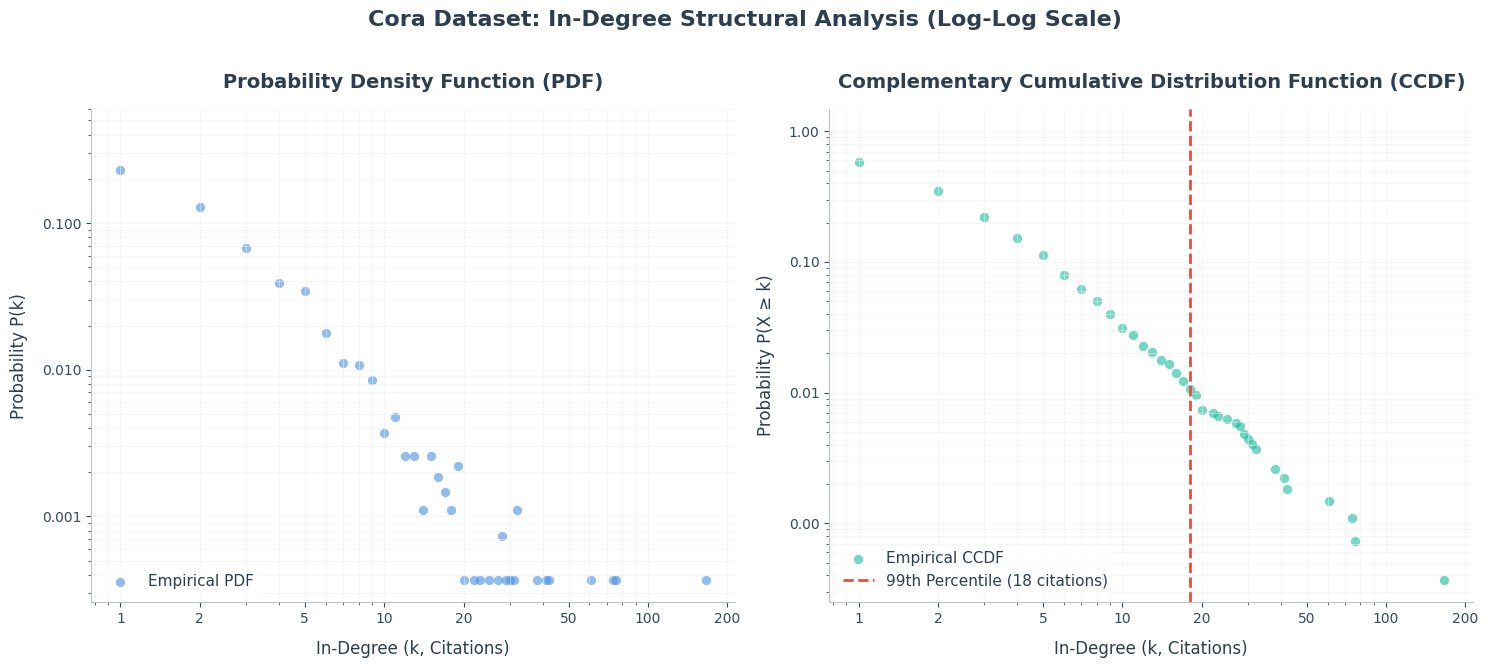

In [103]:
# Count frequencies of unique in-degree values
in_counts = Counter(in_degree_values)
in_degrees_unique = np.array(sorted(in_counts.keys()))
in_degrees_freq = np.array([in_counts[d] for d in in_degrees_unique])

# Compute Probability Density Function (PDF)
in_pdf = in_degrees_freq / len(in_degree_values)

# Compute Complementary Cumulative Distribution Function (CCDF): 1 - P(X >= k)
in_ccdf = np.cumsum(in_degrees_freq[::-1])[::-1] / len(in_degree_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#ffffff')

# Subplot 1: Probability Density Function (PDF)
axes[0].scatter(in_degrees_unique, in_pdf, color='#4a90e2', alpha=0.6, s=45, linewidths=0, label='Empirical PDF')
format_log_axes(axes[0])
axes[0].set_title('Probability Density Function (PDF)', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
axes[0].set_xlabel('In-Degree (k, Citations)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Probability P(k)', fontsize=12, labelpad=10)
axes[0].legend(fontsize=11, loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='none')

# Subplot 2: Complementary Cumulative Distribution Function (CCDF)
axes[1].scatter(in_degrees_unique, in_ccdf, color='#1abc9c', alpha=0.6, s=45, linewidths=0, label='Empirical CCDF')

# Visual marker for the 99th percentile (Oligarchy threshold)
axes[1].axvline(x=hub_threshold, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'99th Percentile ({int(hub_threshold)} citations)')
format_log_axes(axes[1])
axes[1].set_title('Complementary Cumulative Distribution Function (CCDF)', fontsize=14, fontweight='bold', pad=15,
                  color='#2c3e50')
axes[1].set_xlabel('In-Degree (k, Citations)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Probability P(X ≥ k)', fontsize=12, labelpad=10)
axes[1].legend(fontsize=11, loc='lower left', frameon=True, facecolor='#ffffff', edgecolor='none')

# Override x-ticks (log-like...)
for ax in axes:
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

plt.suptitle('Cora Dataset: In-Degree Structural Analysis (Log-Log Scale)', fontsize=16, fontweight='bold',
             color='#2c3e50', y=1.02)
plt.tight_layout()
plt.savefig('./images/pdf_cdf_in_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Baseline check (Erdős-Rényi Graph)

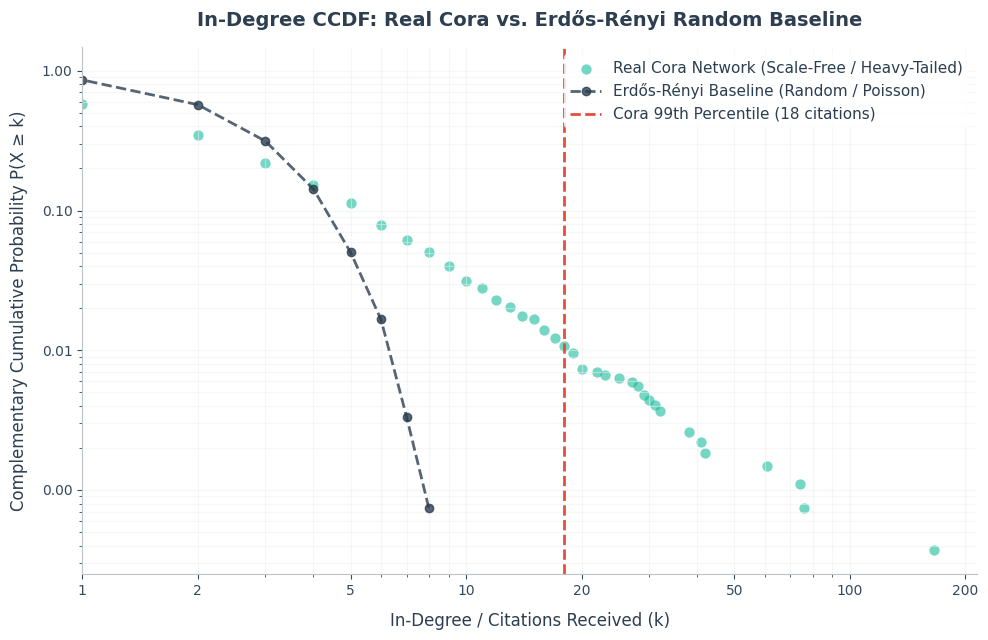

In [104]:
# Generate Erdős-Rényi Baseline Model
p_edge = num_edges / (num_nodes * (num_nodes - 1))  # Probability of an edge: E / (V * (V-1))
G_erdos = nx.erdos_renyi_graph(num_nodes, p_edge, directed=True, seed=42)

# Extract Erdős-Rényi In-Degrees
erdos_values = np.array([d for n, d in G_erdos.in_degree()])
erdos_counts = Counter(erdos_values)
erdos_degrees_unique = np.array(sorted(erdos_counts.keys()))
erdos_ccdf = np.array([np.sum(erdos_values >= k) / num_nodes for k in erdos_degrees_unique])

# Plotting the Scientific Comparison
plt.figure(figsize=(10, 6.5), facecolor='#ffffff')

# Plot Cora (Scale-Free Power Law) - Teal/Verde Acqua scatter points
plt.scatter(in_degrees_unique, in_ccdf, color='#1abc9c', alpha=0.6, s=55, linewidths=0,
            label='Real Cora Network (Scale-Free / Heavy-Tailed)')

# Plot Erdős-Rényi (Poisson / Random) - Black dashed line with markers
plt.plot(erdos_degrees_unique, erdos_ccdf, color='#2c3e50', linestyle='--', linewidth=2,
         marker='o', markersize=6, alpha=0.8, label='Erdős-Rényi Baseline (Random / Poisson)')

# Highlight the 99th Percentile of Cora - Coral Red vertical line
plt.axvline(x=hub_threshold, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Cora 99th Percentile ({int(hub_threshold)} citations)')

ax = plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')

# Force real integer formatting on axes instead of standard 10^n scientific notation
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='both')

# Override x-ticks (log-like...)
ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

# Clean grid lines and remove unnecessary top/right spines
ax.grid(True, which="both", ls="-", color='#ecf0f1', linewidth=0.8)
ax.set_facecolor('#ffffff')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Labels, Legend & Figure Export
plt.title('In-Degree CCDF: Real Cora vs. Erdős-Rényi Random Baseline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('In-Degree / Citations Received (k)', fontsize=12, labelpad=10)
plt.ylabel('Complementary Cumulative Probability P(X ≥ k)', fontsize=12, labelpad=10)
plt.legend(fontsize=11, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')

plt.xlim(left=1)
plt.tight_layout()

plt.savefig('./images/pdf_cdf_in_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 2) Milestone Papers vs. Literature Reviews: how do they behave?
How can we mathematically distinguish a groundbreaking paper that founded a discipline from a paper that simply did an excellent job summarizing existing literature?

### Out-Degree Statistics (and comparison with In-Degree)

In [105]:
# Degree Computations (In VS Out)
out_values = np.array([d for n, d in G.out_degree()])

print("=== DIRECTIONAL DEGREE ASYMMETRY ANALYSIS ===")
pd.DataFrame({
    "Directional Metric": [
        "Mean (Average)",
        "Standard Deviation (Std)",
        "Minimum",
        "Maximum"
    ],
    "In-Degree (Citations Received)": [
        np.mean(in_degree_values),
        np.std(in_degree_values),
        float(np.min(in_degree_values)),
        float(np.max(in_degree_values))
    ],
    "Out-Degree (References Made)": [
        np.mean(out_values),
        np.std(out_values),
        float(np.min(out_values)),
        float(np.max(out_values))
    ]
})

=== DIRECTIONAL DEGREE ASYMMETRY ANALYSIS ===


,Directional Metric,In-Degree (Citations Received),Out-Degree (References Made)
0,Mean (Average),2.004801,2.004801
1,Standard Deviation (Std),5.218170,1.478419
2,Minimum,0.000000,0.000000
3,Maximum,166.000000,5.000000


### In-Degree vs Out-Degree CCDF Comparison

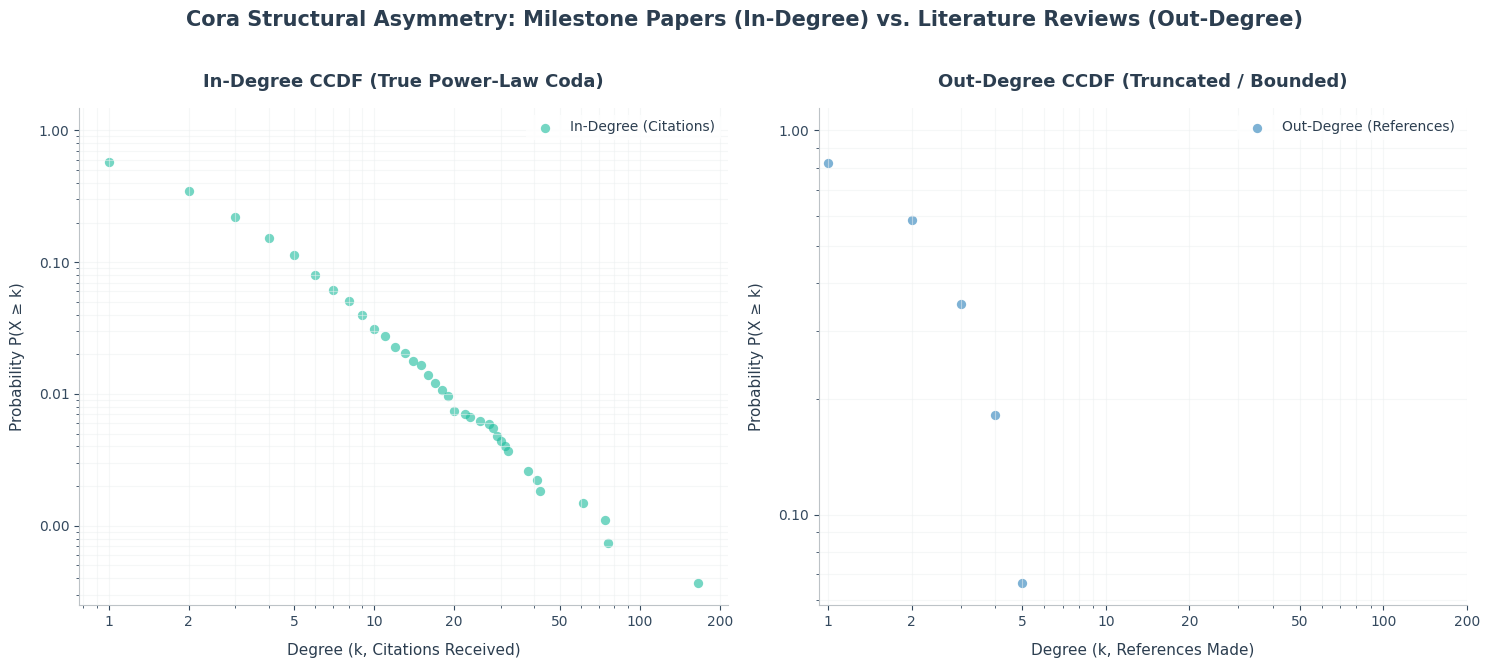

In [106]:
# Compute CCDF for Out-Degree
out_counts = Counter(out_values)
out_deg_unique = np.array(sorted(out_counts.keys()))
out_degrees_freq = np.array([out_counts[d] for d in out_deg_unique])
out_ccdf = np.cumsum(out_degrees_freq[::-1])[::-1] / len(out_values)

# Plotting: The Structural Asymmetry (In vs. Out CCDF)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#ffffff')

# SUBPLOT 1: In-Degree CCDF (Authorities)
axes[0].scatter(in_degrees_unique, in_ccdf, color='#1abc9c', alpha=0.6, s=45,
                linewidths=0, label='In-Degree (Citations)')
format_log_axes(axes[0])
axes[0].set_title('In-Degree CCDF (True Power-Law Coda)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Degree (k, Citations Received)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Probability P(X ≥ k)', fontsize=11, labelpad=10)
axes[0].legend(fontsize=10, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')

# SUBPLOT 2: Out-Degree CCDF (Hubs)
axes[1].scatter(out_deg_unique, out_ccdf, color='#2980b9', alpha=0.6, s=45,
                linewidths=0, label='Out-Degree (References)')
format_log_axes(axes[1])
axes[1].set_title('Out-Degree CCDF (Truncated / Bounded)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Degree (k, References Made)', fontsize=11, labelpad=10)
axes[1].set_ylabel('Probability P(X ≥ k)', fontsize=11, labelpad=10)
axes[1].legend(fontsize=10, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')

# Override x-ticks (log-like...)
for ax in axes:
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

plt.suptitle('Cora Structural Asymmetry: Milestone Papers (In-Degree) vs. Literature Reviews (Out-Degree)',
             fontsize=15, fontweight='bold', color='#2c3e50', y=1.02)

plt.tight_layout()
plt.savefig('./images/cora_hits_asymmetry.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Hubs

In [107]:
# Computing degree authorities by keeping only degrees above 99 percentiles
degree_authorities = [node for node, deg in G.in_degree() if deg >= hub_threshold]
num_auths = len(degree_authorities)

# Getting top authorities
top_auth = max(G.in_degree(), key=lambda x: x[1])
top_node_id = top_auth[0]
edge_share = (top_auth[1] / num_edges) * 100

# Getting top authorities fields
auth_fields = [G.nodes[node].get('field', 'Unknown') for node in degree_authorities]
field_counts = Counter(auth_fields)

print("=== AUTHORITY ELITE DETECTION (Top 1% Most Cited) ===")
df_elite_report = pd.DataFrame({
    "Detection Metric": ["In-Degree Threshold (99th Percentile)", "Elite Population Count", "Total Network Population",
                         "Elite Proportion"],
    "Value": [f"{hub_threshold:.1f} citations", f"{num_auths} papers", f"{num_nodes} papers",
              f"{(num_auths / num_nodes) * 100:.2f}% of network"]
})
display(df_elite_report.style.hide(axis='index'))

print("\n=== THE ULTIMATE NETWORK AUTHORITY PROFILE ===")
df_top_profile = pd.DataFrame({
    "Property": ["Paper ID", "Total Citations Received", "Academic Field", "Global Edge Market Share"],
    "Value": [str(top_node_id), f"{top_auth[1]}", G.nodes[top_node_id].get('field', 'Unknown'),
              f"{edge_share:.2f}% of all network edges"]
})
display(df_top_profile.style.hide(axis='index'))

print("\n=== FIELD DISTRIBUTION AMONG THE ARISTOCRACY ===")
df_fields_elite = pd.DataFrame([
    {"Academic Field": field, "Elite Count": count, "Share of Elite (%)": (count / num_auths) * 100}
    for field, count in field_counts.most_common()
])
display(df_fields_elite.style.format({"Share of Elite (%)": "{:.2f}%".format}).hide(axis='index'))

=== AUTHORITY ELITE DETECTION (Top 1% Most Cited) ===


Detection Metric,Value
In-Degree Threshold (99th Percentile),18.0 citations
Elite Population Count,29 papers
Total Network Population,2708 papers
Elite Proportion,1.07% of network



=== THE ULTIMATE NETWORK AUTHORITY PROFILE ===


Property,Value
Paper ID,35
Total Citations Received,166
Academic Field,Genetic_Algorithms
Global Edge Market Share,3.06% of all network edges



=== FIELD DISTRIBUTION AMONG THE ARISTOCRACY ===


Academic Field,Elite Count,Share of Elite (%)
Theory,9,31.03%
Neural_Networks,8,27.59%
Genetic_Algorithms,4,13.79%
Reinforcement_Learning,4,13.79%
Probabilistic_Methods,2,6.90%
Rule_Learning,1,3.45%
Case_Based,1,3.45%


## 3) Does science advance in isolated silos or via cross-disciplinary contamination?
Do scientists exclusively cite peers who share their exact sub-field, or do they actively browse and integrate external disciplines?

### Attribute Assortativity Coefficient

In [108]:
# Computing assortativity to check for Homophily
assortativity_field = nx.attribute_assortativity_coefficient(G, "field")

if assortativity_field > 0.3:
    regime = "Strong Assortativity (Homophily)"
    desc = "Cultural Silos: Papers strongly prefer to cite within their own academic field. Knowledge is highly segregated."
elif assortativity_field > 0.1:
    regime = "Moderate Assortativity"
    desc = "Visible Discipline Borders: In-field citations are preferred, but cross-disciplinary dialogue is present."
elif assortativity_field < -0.1:
    regime = "Disassortativity (Heterophily)"
    desc = "Interdisciplinary Bridges: Papers preferentially cite outside their own field, suggesting a complementary ecosystem."
else:
    regime = "Neutral / Random Mixing"
    desc = "Topology-Blind Citations: The field category does not mathematically dictate or restrict citation patterns."

assortativity_data = {
    "Network Dimension": ["Target Attribute", "Assortativity Coefficient ($r$)", "Mixing Regime",
                          "Structural Interpretation"],
    "Value": ["field (Academic Subject)", f"{assortativity_field:.4f}", regime, desc]
}

print("=== COGNITIVE HOMOPHILY REPORT: THE ASSORTATIVITY INDEX ===")
pd.DataFrame(assortativity_data)

=== COGNITIVE HOMOPHILY REPORT: THE ASSORTATIVITY INDEX ===


,Network Dimension,Value
0,Target Attribute,field (Academic Subject)
1,Assortativity Coefficient ($r$),0.7755
2,Mixing Regime,Strong Assortativity (Homophily)
3,Structural Interpretation,Cultural Silos: Papers strongly prefer to cite...


### Attribute Mixing Matrix

In [109]:
# Mixing matrix preparation
fields_list = sorted(list(set(nx.get_node_attributes(G, "field").values())))
mixing_matrix = nx.attribute_mixing_matrix(G, "field", mapping={f: i for i, f in enumerate(fields_list)})
mixing_df = pd.DataFrame(mixing_matrix, index=fields_list, columns=fields_list)

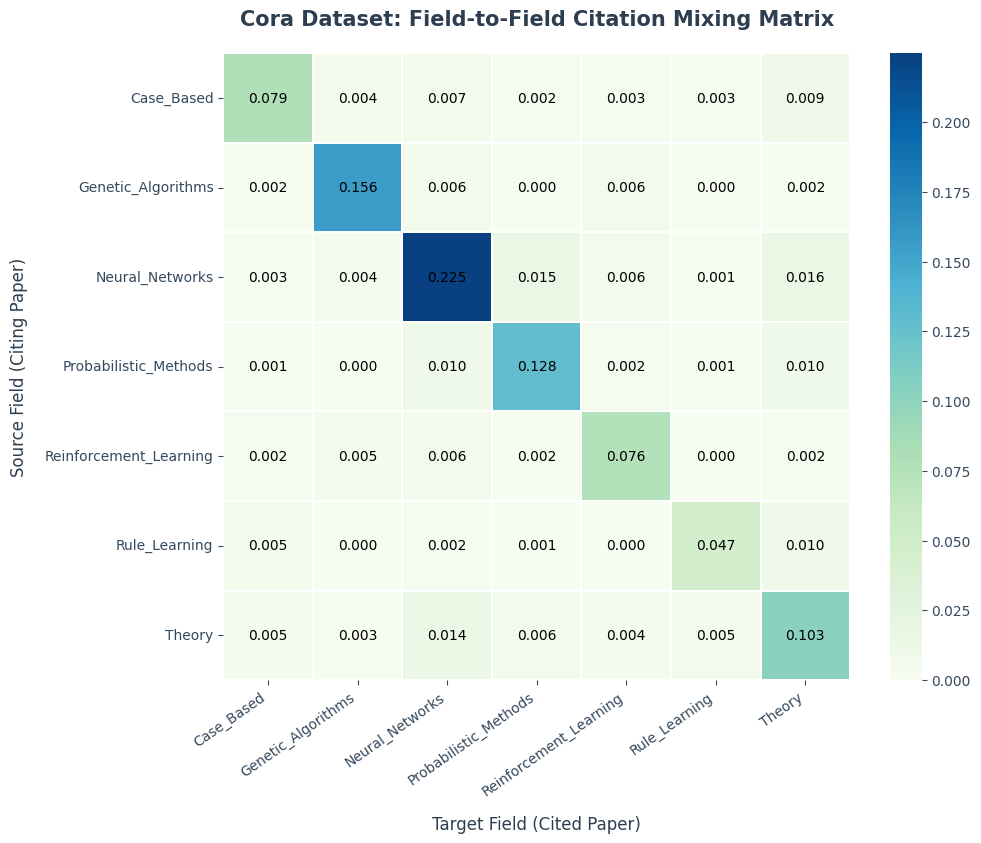

In [110]:
# Heatmap Visualization of mixing matrix
plt.figure(figsize=(10.5, 8.5), facecolor='#ffffff')

ax = sns.heatmap(mixing_df,
                 annot=True,
                 fmt=".3f",
                 cmap="GnBu",
                 cbar=True,
                 square=True,
                 linewidths=1.2,
                 linecolor='#ffffff',
                 annot_kws={"size": 10, "weight": "medium", "color": "#000000"})

# Refined Typography and Labeling
plt.title("Cora Dataset: Field-to-Field Citation Mixing Matrix", fontsize=15, fontweight='bold', pad=20,
          color='#2c3e50')
plt.xlabel("Target Field (Cited Paper)", fontsize=12, labelpad=12)
plt.ylabel("Source Field (Citing Paper)", fontsize=12, labelpad=12)

# Rotate labels precisely to prevent overlaps and ensure high readability
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Clean up axes spines for a modern, borderless flat-design look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('./images/cora_assortativity_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Analytical Homophily Test ($\rho \ll 2pq$)

In [111]:
# Count edges where source and target belong to different academic fields
cross_edges_count = sum(
    1 for u, v in G.edges()
    if G.nodes[u].get("field") != G.nodes[v].get("field")
    # Getting only edges where source and target are in different fields (cross-characteristics)
)
rho = cross_edges_count / num_edges

# Extract node field distributions to calculate random baseline probabilities
node_fields = [G.nodes[n].get("field") for n in G.nodes() if G.nodes[n].get("field") is not None]
field_counts = pd.Series(node_fields).value_counts()
field_probabilities = field_counts / len(node_fields)

# Expected cross-fraction under random mixing: 1 - sum(p_i^2)
expected_cross_fraction = 1.0 - np.sum(field_probabilities ** 2)
ratio = rho / expected_cross_fraction

# Evaluate Statistical Homophily Verdict
if rho < expected_cross_fraction:
    verdict = "HOMOPHILY CONFIRMED"
    interpretation = f"The actual cross-field citation rate is suppressed, reaching only {ratio:.2%} of what random chance predicts."
else:
    verdict = "NO HOMOPHILY / HETEROPHILY"
    interpretation = "Citations cross disciplinary boundaries as much as or more than expected by pure chance."

# Structure and Render Results
homophily_test_data = {
    "Analytical Metric": [
        "Observed Cross-Edges Fraction (ρ)",
        "Expected Random Cross Fraction ($1 - \\sum p_i^2$)",
        "Suppression Ratio (Observed / Expected)",
        "Statistical Verdict",
        "Physical Meaning"
    ],
    "Value / Result": [
        f"{rho:.4%}",
        f"{expected_cross_fraction:.4%}",
        f"{ratio:.4f}",
        verdict,
        interpretation
    ]
}

df_homophily_test = pd.DataFrame(homophily_test_data)

print("=== ANALYTICAL HOMOPHILY TEST: EMPIRICAL VS NULL MODEL ===")
display(df_homophily_test)

=== ANALYTICAL HOMOPHILY TEST: EMPIRICAL VS NULL MODEL ===


,Analytical Metric,Value / Result
0,Observed Cross-Edges Fraction (ρ),18.6222%
1,Expected Random Cross Fraction ($1 - \sum p_i^2$),82.0432%
2,Suppression Ratio (Observed / Expected),0.2270
3,Statistical Verdict,HOMOPHILY CONFIRMED
4,Physical Meaning,The actual cross-field citation rate is suppre...


## 4) If the Network is segregated into silos, how does information ever circulate globally?
How can we reconcile a network heavily fractured into isolated academic disciplines with the Small-World phenomenon, which states that any two papers are separated by only a few steps? Who acts as the structural glue?

### Connected Components

In [112]:
# Getting the giant component
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))

# Finding the largest component
largest_scc_nodes = max(scc, key=len)
largest_wcc_nodes = max(wcc, key=len)

# Computing the size of the largest component
largest_scc_size = len(largest_scc_nodes)
largest_wcc_size = len(largest_wcc_nodes)

print("=== MACROSCOPIC CONNECTIVITY: COMPONENT ANALYSIS ===")
pd.DataFrame({
    "Topology Type": [
        "Strongly Connected (SCC - Mutual Paths)",
        "Weakly Connected (WCC - Ignore Direction)"
    ],
    "Total Components Found": [len(scc), len(wcc)],
    "Giant Component Size (Nodes)": [largest_scc_size, largest_wcc_size],
    "Network Absorption Share": [
        f"{(largest_scc_size / num_nodes) * 100:.2f}%",
        f"{(largest_wcc_size / num_nodes) * 100:.2f}%"
    ]
})

=== MACROSCOPIC CONNECTIVITY: COMPONENT ANALYSIS ===


,Topology Type,Total Components Found,Giant Component Size (Nodes),Network Absorption Share
0,Strongly Connected (SCC - Mutual Paths),2526,13,0.48%
1,Weakly Connected (WCC - Ignore Direction),78,2485,91.77%


### Giant Component

In [113]:
# Giant Component (GCC) is the largest component in the network, which is the most densely connected subgraph.
G_gcc_directed = G.subgraph(largest_wcc_nodes)
G_gcc_undirected = G_gcc_directed.to_undirected()
n_gcc = G_gcc_undirected.number_of_nodes()
e_gcc = G_gcc_undirected.number_of_edges()

print("\n=== GIANT CONNECTED COMPONENT (GCC) PROFILE ===")
print("Note: Graph direction removed to compute distance metrics (Diameter & Path Lengths)")
pd.DataFrame({
    "GCC Structural Property": [
        "Nodes Isolate in GCC ($N_{gcc}$)",
        "Edges in Undirected GCC ($E_{gcc}$)",
        "GCC Population Coverage",
    ],
    "Value / Metric": [
        f"{n_gcc:,}",
        f"{e_gcc:,}",
        f"{(n_gcc / num_nodes) * 100:.2f}% of total graph"
    ]
})


=== GIANT CONNECTED COMPONENT (GCC) PROFILE ===
Note: Graph direction removed to compute distance metrics (Diameter & Path Lengths)


,GCC Structural Property,Value / Metric
0,Nodes Isolate in GCC ($N_{gcc}$),"2,485"
1,Edges in Undirected GCC ($E_{gcc}$),"5,069"
2,GCC Population Coverage,91.77% of total graph


### Reciprocity

In [114]:
# Computing global reciprocity coefficient
global_reciprocity = nx.overall_reciprocity(G)

# Getting all reciprocal edges in the network
reciprocal_pairs = set()
for u, v in G.edges():
    if u < v and G.has_edge(v, u):
        reciprocal_pairs.add((u, v))

# Extracting reciprocal edge pairs
reciprocal_list = list(reciprocal_pairs)
num_reciprocal_pairs = len(reciprocal_list)

print("=== GLOBAL NETWORK RECIPROCITY REPORT ===")
pd.DataFrame({
    "Metric": [
        "Global Reciprocity Coefficient",
        "Reciprocal Edge Pairs Count",
        "Total Directed Edges (E)",
        "Percentage of Reciprocal Links"
    ],
    "Value": [
        f"{global_reciprocity:.6f}",
        f"{num_reciprocal_pairs:,}",
        f"{G.number_of_edges():,}",
        f"{(num_reciprocal_pairs * 2 / G.number_of_edges()) * 100:.4f}%"
    ],
    "Structural Meaning": [
        "Probability that a random directed edge is mutually returned",
        "Absolute number of mutual citation loops (A <---> B)",
        "Global baseline of directed arrows in the network",
        "Share of connectivity dedicated to mutual interaction"
    ]
})

=== GLOBAL NETWORK RECIPROCITY REPORT ===


,Metric,Value,Structural Meaning
0,Global Reciprocity Coefficient,0.055627,Probability that a random directed edge is mut...
1,Reciprocal Edge Pairs Count,151,Absolute number of mutual citation loops (A <-...
2,Total Directed Edges (E),"5,429",Global baseline of directed arrows in the network
3,Percentage of Reciprocal Links,5.5627%,Share of connectivity dedicated to mutual inte...


In [115]:
# Checking for isolated nodes in the GCC
if num_reciprocal_pairs > 0:
    sample_rows = []
    for u, v in reciprocal_list[:5]:
        field_u = G.nodes[u].get('field', 'Unknown')
        field_v = G.nodes[v].get('field', 'Unknown')
        same_field = "YES" if field_u == field_v else "NO (Cross-Disciplinary)"

        sample_rows.append({
            "Source ID": u,
            "Source Field": field_u,
            "Target ID": v,
            "Target Field": field_v,
            "Homophilic Pair?": same_field
        })
    df_sample = pd.DataFrame(sample_rows)
else:
    df_sample = pd.DataFrame(columns=["Status"], data=[["No reciprocal edges found in the network."]])

print("\n=== QUALITATIVE SAMPLE OF MUTUAL CITATIONS (First 5 Pairs) ===")
display(df_sample)


=== QUALITATIVE SAMPLE OF MUTUAL CITATIONS (First 5 Pairs) ===


,Source ID,Source Field,Target ID,Target Field,Homophilic Pair?
0,31769,Neural_Networks,67245,Neural_Networks,YES
1,16819,Probabilistic_Methods,643221,Probabilistic_Methods,YES
2,155736,Theory,155738,Theory,YES
3,14429,Probabilistic_Methods,73119,Probabilistic_Methods,YES
4,11326,Theory,11339,Theory,YES


### Average Shortest Path Length

In [116]:
# Getting average shortest path length
L_real = nx.average_shortest_path_length(G_gcc_undirected)

# Computing average shortest path length under random connectivity
k_avg = (2 * e_gcc) / n_gcc
L_rand = np.log(n_gcc) / np.log(k_avg)

print("=== GLOBAL DISTANCE & NAVIGATION ANALYSIS ===")
print(f"GCC Average Degree ⟨k⟩: {k_avg:.4f}")
pd.DataFrame({
    "Network Architecture": [
        "Real Cora GCC (Empirical)",
        "Erdős-Rényi Baseline (Random)",
        "Structural Proximity Ratio"
    ],
    "Average Path Length ($L$)": [
        L_real,
        L_rand,
        L_real / L_rand
    ],
    "Topological Interpretation": [
        f"Average separation between any two papers in the main component.",
        f"Theoretical path length if links were wired completely at random.",
        f"Efficiency factor. Values close to 1.0 indicate optimal Small-World navigation."
    ]
})

=== GLOBAL DISTANCE & NAVIGATION ANALYSIS ===
GCC Average Degree ⟨k⟩: 4.0797


,Network Architecture,Average Path Length ($L$),Topological Interpretation
0,Real Cora GCC (Empirical),6.310999,Average separation between any two papers in t...
1,Erdős-Rényi Baseline (Random),5.560404,Theoretical path length if links were wired co...
2,Structural Proximity Ratio,1.134989,Efficiency factor. Values close to 1.0 indicat...


### Average Clustering Coefficient

In [117]:
# Getting average clustering coefficient
C_real = nx.average_clustering(G_gcc_undirected)

# Computing average clustering coefficient under random connectivity
C_rand = k_avg / n_gcc
clustering_amplification = C_real / C_rand

print("=== LOCAL TRANSITIVITY & TRIADIC CLOSURE REPORT ===")
pd.DataFrame({
    "Network Topology": [
        "Real Cora GCC (Empirical)",
        "Erdős-Rényi Baseline (Random)",
        "Clustering Amplification ($C_{real} / C_{rand}$)"
    ],
    "Clustering Coefficient ($C$)": [
        C_real,
        C_rand,
        clustering_amplification
    ],
    "Topological Meaning": [
        "Probability that two papers cited by the same document are also connected to each other.",
        "Expected clustering if edge interconnections occurred purely by blind chance.",
        "The factor by which the real network exceeds random triadic closure. Crucial for Small-World verification."
    ]
})

=== LOCAL TRANSITIVITY & TRIADIC CLOSURE REPORT ===


,Network Topology,Clustering Coefficient ($C$),Topological Meaning
0,Real Cora GCC (Empirical),0.237636,Probability that two papers cited by the same ...
1,Erdős-Rényi Baseline (Random),0.001642,Expected clustering if edge interconnections o...
2,Clustering Amplification ($C_{real} / C_{rand}$),144.747756,The factor by which the real network exceeds r...


### Small-World

In [118]:
# Calculating the Small-World metric
gamma = C_real / C_rand
lam = L_real / L_rand
sigma = gamma / lam

# Verifying the Small-World condition
is_small_world = sigma > 1.0 and gamma > 1.0 and abs(lam - 1.0) < 0.5

if is_small_world:
    verdict = "CONFIRMED (Strong Small-World Properties)"
    conclusion_text = (
        f"Cora is a Small-World network. High local cohesiveness (𝛾 >> 1) "
        f"coexists with global navigational efficiency (𝜆 ≈ 1). You can cross "
        f"the whole network in just {np.ceil(L_real):.0f} citation steps on average."
    )
else:
    verdict = "NOT RECOGNIZED"
    conclusion_text = "The network topological parameters do not satisfy the joint Humphries-Gurney criteria."

print("=== RATIOS & HUMPHRIES-GURNEY SMALL-WORLDNESS INDEX ===")
pd.DataFrame({
    "Small-World Metric": [
        "Clustering Ratio",
        "Path Length Ratio",
        "Small-Worldness Index",
        "Empirical Verdict",
        "Topological Summary"
    ],
    "Calculated Value": [
        f"{gamma:.4f}",
        f"{lam:.4f}",
        f"{sigma:.4f}",
        verdict,
        conclusion_text
    ],
    "Theoretical Acceptance Threshold": [
        "𝛾 >> 1 (Massive local clustering amplification)",
        "𝜆 ≈ 1 (Logarithmic distance scalability)",
        "𝜎 > 1 (Formal Small-World validation)",
        "All 3 criteria must be simultaneously met",
        "Physical implication on scientific knowledge diffusion"
    ]
})

=== RATIOS & HUMPHRIES-GURNEY SMALL-WORLDNESS INDEX ===


,Small-World Metric,Calculated Value,Theoretical Acceptance Threshold
0,Clustering Ratio,144.7478,𝛾 >> 1 (Massive local clustering amplification)
1,Path Length Ratio,1.1350,𝜆 ≈ 1 (Logarithmic distance scalability)
2,Small-Worldness Index,127.5323,𝜎 > 1 (Formal Small-World validation)
3,Empirical Verdict,CONFIRMED (Strong Small-World Properties),All 3 criteria must be simultaneously met
4,Topological Summary,Cora is a Small-World network. High local cohe...,Physical implication on scientific knowledge d...


### (Cora vs ER vs Configuration Model)

In [119]:
# Computing undirected for performance reasons...
G_real_und = G.to_undirected()

# Compute Real Network Metrics
metrics_real = {
    "Baseline Model": "Real Cora Network",
    "Nodes ($N$)": num_nodes,
    "Edges ($E$)": num_edges,
    "Avg Clustering ($C$)": nx.average_clustering(G_real_und),
    "Transitivity ($T$)": nx.transitivity(G_real_und),
    "Number of WCC": nx.number_weakly_connected_components(G),
    "Global Reciprocity ($r$)": nx.overall_reciprocity(G)
}

# Baseline Model A: Erdős-Rényi Random Graph
p_edge = num_edges / (num_nodes * (num_nodes - 1))
G_erdos = nx.erdos_renyi_graph(num_nodes, p_edge, directed=True, seed=42)
G_erdos_und = G_erdos.to_undirected()

metrics_erdos = {
    "Baseline Model": "Erdős-Rényi (Random)",
    "Nodes ($N$)": G_erdos.number_of_nodes(),
    "Edges ($E$)": G_erdos.number_of_edges(),
    "Avg Clustering ($C$)": nx.average_clustering(G_erdos_und),
    "Transitivity ($T$)": nx.transitivity(G_erdos_und),
    "Number of WCC": nx.number_weakly_connected_components(G_erdos),
    "Global Reciprocity ($r$)": nx.overall_reciprocity(G_erdos)
}

# Baseline Model B: Directed Configuration Model
# This preserves the exact in-degree and out-degree sequences of Cora
in_deg_sequence = [d for n, d in G.in_degree()]
out_deg_sequence = [d for n, d in G.out_degree()]

G_config_multi = nx.directed_configuration_model(in_deg_sequence, out_deg_sequence, seed=42)
G_config = nx.DiGraph(G_config_multi)
G_config.remove_edges_from(nx.selfloop_edges(G_config))
G_config_und = G_config.to_undirected()

metrics_config = {"Baseline Model": "Configuration Model (Degree-Preserved)", "Nodes ($N$)": G_config.number_of_nodes(),
                  "Edges ($E$)": G_config_multi.number_of_edges(),
                  "Avg Clustering ($C$)": nx.average_clustering(G_config_und),
                  "Transitivity ($T$)": nx.transitivity(G_config_und),
                  "Number of WCC": nx.number_weakly_connected_components(G_config),
                  "Global Reciprocity ($r$)": nx.overall_reciprocity(G_config)}

print("=== BASELINE MODELS COMPARISON TABLE ===")
pd.DataFrame([metrics_real, metrics_erdos, metrics_config])

=== BASELINE MODELS COMPARISON TABLE ===


,Baseline Model,Nodes ($N$),Edges ($E$),Avg Clustering ($C$),Transitivity ($T$),Number of WCC,Global Reciprocity ($r$)
0,Real Cora Network,2708,5429,0.240673,0.093497,78,0.055627
1,Erdős-Rényi (Random),2708,5308,0.000547,0.000725,61,0.000377
2,Configuration Model (Degree-Preserved),2708,5429,0.004361,0.003139,13,0.000739


### Betweenness Centrality

In [120]:
# Computing betweenness centrality
betweenness = nx.betweenness_centrality(G)

rows = []
for node, score in betweenness.items():
    rows.append({
        "Node": node,
        "Betweenness": score,
        "In_degree": G.in_degree(node),
        "Field": G.nodes[node].get('field', 'unknown')
    })

pd.DataFrame(rows).sort_values("Field", ascending=False).head(10)

,Node,Betweenness,In_degree,Field
2217,128202,0.000000,0,Theory
1979,59626,0.000000,5,Theory
1131,23738,0.000242,15,Theory
1965,711527,0.000000,0,Theory
1266,1119471,0.000000,0,Theory
1267,12169,0.000000,3,Theory
1268,1059953,0.000000,0,Theory
1269,1106418,0.000000,0,Theory
2134,93755,0.000000,1,Theory
1270,1117249,0.000000,0,Theory


### Neighborhood Overlap (Granovetter Theory)

In [121]:
# Computing neighbors dictionary (undirected)
neighbors_dict = {n: set(G_real_und.neighbors(n)) for n in G_real_und.nodes()}

# Getting the fields
fields_dict = {n: G.nodes[n].get("field", "unknown") for n in G_real_und.nodes()}

# Computing the overlap between neighbors
edge_data = []
for u, v in G_real_und.edges():
    nu = neighbors_dict[u]
    nv = neighbors_dict[v]

    intersection_len = len(nu & nv)
    union_len = len(nu | nv) - 2  # Escludiamo u e v dall'unione

    overlap = intersection_len / union_len if union_len > 0 else 0.0

    edge_data.append({
        "overlap": overlap,
        "is_local_bridge": overlap == 0.0,
        "is_cross_field": fields_dict[u] != fields_dict[v]
    })

df_edges = pd.DataFrame(edge_data)

local_bridges_count = df_edges["is_local_bridge"].sum()

avg_overlap_inside = df_edges[df_edges["is_cross_field"] == False]["overlap"].mean()
avg_overlap_cross = df_edges[df_edges["is_cross_field"] == True]["overlap"].mean()

df_bridges = df_edges[df_edges["is_local_bridge"] == True]
cross_field_bridges_pct = df_bridges["is_cross_field"].mean() if len(df_bridges) > 0 else 0.0

In [122]:
print("=== TOPOLOGICAL STRUCTURE: NEIGHBORHOOD OVERLAP MAP ===")
pd.DataFrame({
    "Topological Metric": [
        "Total Undirected Edges ($E_{und}$)",
        "Local Bridges Detected (Overlap = 0)",
        "Local Bridges Share (%)"
    ],
    "Value": [
        f"{num_edges:,}",
        f"{local_bridges_count:,}",
        f"{(local_bridges_count / num_edges) * 100:.2f}%"
    ],
    "Granovetter Meaning": [
        "Total communication channels in the undirected layout.",
        "Links whose removal strictly increases the distance between their endpoints.",
        "The proportion of the network acting as purely structural shortcuts."
    ]
})

=== TOPOLOGICAL STRUCTURE: NEIGHBORHOOD OVERLAP MAP ===


,Topological Metric,Value,Granovetter Meaning
0,Total Undirected Edges ($E_{und}$),"5,429",Total communication channels in the undirected...
1,Local Bridges Detected (Overlap = 0),"2,434",Links whose removal strictly increases the dis...
2,Local Bridges Share (%),44.83%,The proportion of the network acting as purely...


In [123]:
print("\n=== GRANOVETTER'S WEAK TIES MATHEMATICAL VALIDATION ===")
pd.DataFrame({
    "Citation Tie Category": [
        "Same-Field Citations (Intra-Disciplinary)",
        "Cross-Field Citations (Inter-Disciplinary)",
        "Bridges Nature (Share of Interdisciplinarity among Local Bridges)"
    ],
    "Empirical Neighborhood Overlap": [
        f"{avg_overlap_inside:.4f}",
        f"{avg_overlap_cross:.4f}",
        f"{cross_field_bridges_pct:.2%}"
    ],
    "Theoretical Validation Verdict": [
        "STRONG TIES: High overlap. Dense local networks where everyone knows everyone.",
        "WEAK TIES: Low overlap. Links acting as structural conduits between distant groups.",
        "HIGH Local-Bridges: Confirms if bridges are the ones holding different disciplines together."
    ]
})


=== GRANOVETTER'S WEAK TIES MATHEMATICAL VALIDATION ===


,Citation Tie Category,Empirical Neighborhood Overlap,Theoretical Validation Verdict
0,Same-Field Citations (Intra-Disciplinary),0.1283,STRONG TIES: High overlap. Dense local network...
1,Cross-Field Citations (Inter-Disciplinary),0.0541,WEAK TIES: Low overlap. Links acting as struct...
2,Bridges Nature (Share of Interdisciplinarity a...,25.84%,HIGH Local-Bridges: Confirms if bridges are th...


## 5) If we inject an innovative idea into the network, what is its fate?
Does a newly published scientific concept diffuse like a wildfire across the entire academic ecosystem, or does it burn out instantly? How heavily does its survival depend on who introduces it?

### Louvain Community Detection

In [124]:
# Global Community Detection and Modular Scoring
G_undirected = G.to_undirected()
louvain_partition = nx_comm.louvain_communities(G_undirected, seed=42)

# Map nodes to their structural community ID
node_community = {node: i for i, comm in enumerate(louvain_partition) for node in comm}
nx.set_node_attributes(G, node_community, "community")

modularity_score = nx_comm.modularity(G_undirected, louvain_partition)

# Evaluate Partition Similarity Metrics
nodes_ordered = list(G.nodes())
true_labels = [G.nodes[n].get("field") for n in nodes_ordered]
predicted_labels = [G.nodes[n].get("community") for n in nodes_ordered]

ari_score = adjusted_rand_score(true_labels, predicted_labels)
ami_score = adjusted_mutual_info_score(true_labels, predicted_labels)

# Print global metadata metrics
print("=== COMMUNITY DETECTION (LOUVAIN ALGORITHM) ===")
print(f"Number of Communities Detected: {len(louvain_partition)}")
print(f"Network Modularity Score (Q):   {modularity_score:.4f}")
print(f"Adjusted Rand Index (ARI):      {ari_score:.4f}")
print(f"Adjusted Mutual Info (AMI):     {ami_score:.4f}\n")

# Aggregate Composition Data into a Pandas DataFrame
df_nodes = pd.DataFrame({
    "node_id": nodes_ordered,
    "field": true_labels,
    "community": predicted_labels
})

# List to store summary statistics per community
community_summary = []

for comm_id in sorted(df_nodes["community"].unique()):
    comm_subset = df_nodes[df_nodes["community"] == comm_id]
    comm_size = len(comm_subset)

    # Extract structural dominance information
    value_counts = comm_subset["field"].value_counts()
    dominant_field = value_counts.idxmax()
    dominant_field_pct = value_counts.max() / comm_size

    community_summary.append({
        "Community ID": comm_id,
        "Size (Nodes)": comm_size,
        "Dominant Academic Field": dominant_field,
        "Dominance Share": f"{dominant_field_pct:.2%}"
    })

# Convert the summary list to a structured DataFrame
df_communities_composition = pd.DataFrame(community_summary)

print("=== DETECTED COMMUNITIES COMPOSITION ===")
display(df_communities_composition.style.hide(axis='index'))

=== COMMUNITY DETECTION (LOUVAIN ALGORITHM) ===
Number of Communities Detected: 104
Network Modularity Score (Q):   0.8147
Adjusted Rand Index (ARI):      0.2616
Adjusted Mutual Info (AMI):     0.4353

=== DETECTED COMMUNITIES COMPOSITION ===


Community ID,Size (Nodes),Dominant Academic Field,Dominance Share
0,13,Genetic_Algorithms,69.23%
1,29,Probabilistic_Methods,100.00%
2,20,Case_Based,25.00%
3,185,Neural_Networks,84.86%
4,124,Case_Based,89.52%
5,80,Neural_Networks,97.50%
6,98,Probabilistic_Methods,76.53%
7,8,Reinforcement_Learning,50.00%
8,2,Case_Based,50.00%
9,194,Reinforcement_Learning,79.38%


### SIR Model

In [125]:
def simulate_sir_model(graph, seed_nodes, beta=0.20, gamma_par=0.25, max_steps_par=15):
    """
    Simulates information propagation using the SIR model and tracks per-node history.
    """
    # Initialize all nodes as Susceptible
    states = {node: "S" for node in graph.nodes()}

    # Set initial seed nodes as Infected
    for seed in seed_nodes:
        states[seed] = "I"

    # We start the history for each node with its initial state in t=0
    sir_node_history_i = {node: [states[node]] for node in graph.nodes()}

    # Data structures to track global aggregate statistics
    history_S = [sum(1 for n in states if states[n] == "S")]
    history_I = [sum(1 for n in states if states[n] == "I")]
    history_R = [sum(1 for n in states if states[n] == "R")]

    for step in range(max_steps_par):
        next_states = states.copy()
        current_infected = [n for n in states if states[n] == "I"]

        # Infection Phase
        for node in current_infected:
            neighbors = list(graph.predecessors(node))
            for neighbor in neighbors:
                if states[neighbor] == "S":
                    if np.random.rand() < beta:
                        next_states[neighbor] = "I"

        # Recovery Phase
        for node in current_infected:
            if np.random.rand() < gamma_par:
                next_states[node] = "R"

        # Check for early stabilization (no infected nodes left)
        if sum(1 for n in next_states if next_states[n] == "I") == 0:
            states = next_states
            # Saving the stable state for every node till the end of the cycle
            while len(history_I) <= max_steps_par:
                history_S.append(sum(1 for n in states if states[n] == "S"))
                history_I.append(0)
                history_R.append(sum(1 for n in states if states[n] == "R"))

                # Early break nodes update
                for node in graph.nodes():
                    sir_node_history_i[node].append(states[node])
            break

        # Update states and record step statistics
        states = next_states
        history_S.append(sum(1 for n in states if states[n] == "S"))
        history_I.append(sum(1 for n in states if states[n] == "I"))
        history_R.append(sum(1 for n in states if states[n] == "R"))

        # Updating node history
        for node in graph.nodes():
            sir_node_history_i[node].append(states[node])

    # Pandas data-frame creation
    df_stats = pd.DataFrame({
        "Step": list(range(len(history_I))),
        "Susceptible": history_S,
        "Infected": history_I,
        "Recovered": history_R
    })

    return df_stats, sir_node_history_i

Running Monte Carlo simulations... Please wait.


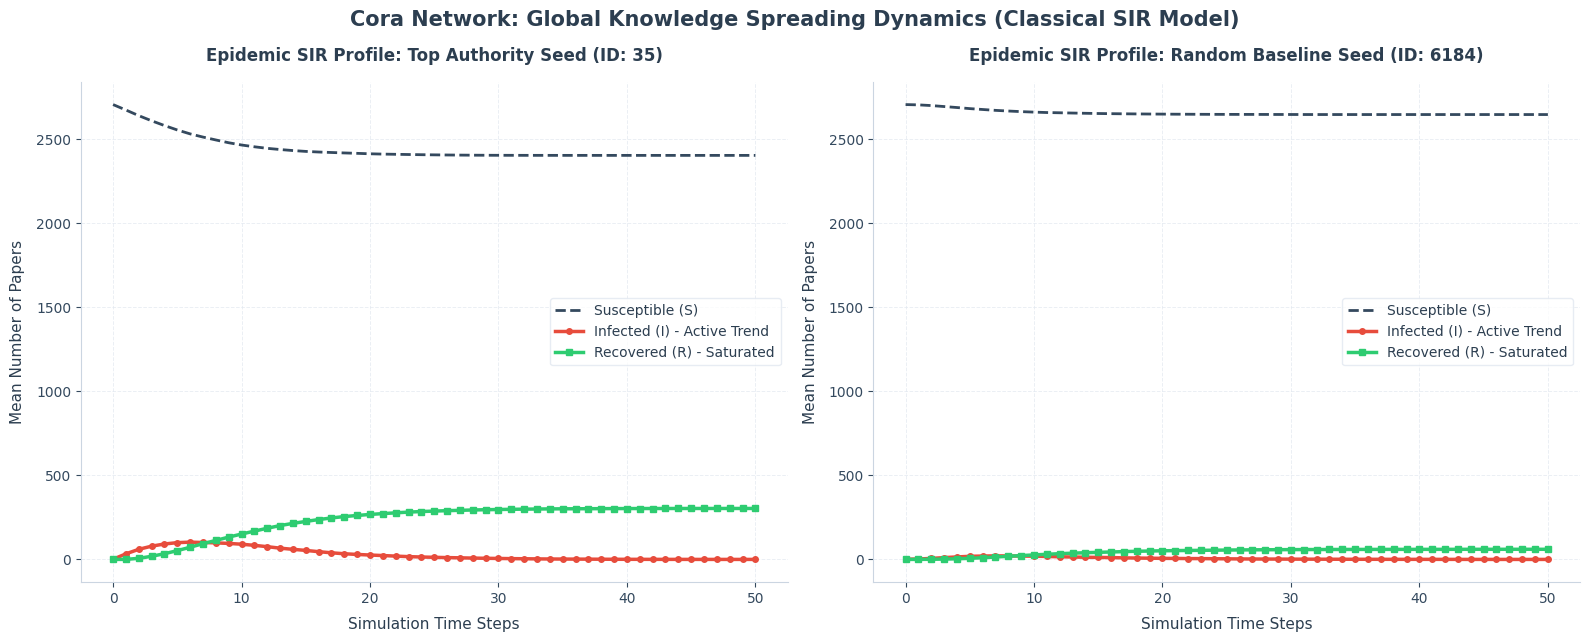

Simulation complete and figure saved successfully.


In [126]:
# Seed Selection Scenarios
top_authority = top_auth[0]
np.random.seed(42)  # Deterministic baseline comparison
random_node = np.random.choice(list(G.nodes()))

# Run Robust Monte Carlo SIR Simulations
num_runs = 50  # 50 for statistical stability
max_steps = 50  # The epidemic on Cora stabilizes very early
beta_param = 0.20  # Infection probability per link
gamma_param = 0.20  # Recovery probability per step

# Lists to collect DataFrames from each random run
auth_dfs = []
rand_dfs = []

# Saving "Top Authority" history
sir_node_history = None

print("Running Monte Carlo simulations... Please wait.")
for i in range(num_runs):
    auth_df, auth_history = simulate_sir_model(G, [top_authority], beta=beta_param, gamma_par=gamma_param,
                                               max_steps_par=max_steps)
    rand_df, _ = simulate_sir_model(G, [random_node], beta=beta_param, gamma_par=gamma_param, max_steps_par=max_steps)

    auth_dfs.append(auth_df)
    rand_dfs.append(rand_df)

    if i == 0:
        sir_node_history = auth_history

# Compute the mean curves by averaging across the DataFrames
auth_mean = pd.concat(auth_dfs).groupby('Step').mean().reset_index()
rand_mean = pd.concat(rand_dfs).groupby('Step').mean().reset_index()

# Plotting the SIR Epidemic Curves (2-Panel Layout)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), facecolor='#ffffff')

# Plot Color Palette (Susceptible = Blue/Grey, Infected = Vibrant Red, Recovered = Clean Green)
colors = {"S": "#34495e", "I": "#e74c3c", "R": "#2ecc71"}

# Panel 1: Top Authority Diffusion Dynamics
ax1.plot(auth_mean['Step'], auth_mean['Susceptible'], label='Susceptible (S)', color=colors["S"], ls='--', lw=2)
ax1.plot(auth_mean['Step'], auth_mean['Infected'], label='Infected (I) - Active Trend', color=colors["I"], marker='o',
         markersize=4, lw=2.5)
ax1.plot(auth_mean['Step'], auth_mean['Recovered'], label='Recovered (R) - Saturated', color=colors["R"], marker='s',
         markersize=4, lw=2.5)

ax1.set_title(f'Epidemic SIR Profile: Top Authority Seed (ID: {top_authority})', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Simulation Time Steps', fontsize=11, labelpad=8)
ax1.set_ylabel('Mean Number of Papers', fontsize=11, labelpad=8)
ax1.grid(True, linestyle='--', linewidth=0.7, color='#e2e8f0', alpha=0.7)
ax1.legend(fontsize=10, loc='center right', frameon=True, edgecolor='#e2e8f0')

# Panel 2: Random Baseline Paper Diffusion Dynamics
ax2.plot(rand_mean['Step'], rand_mean['Susceptible'], label='Susceptible (S)', color=colors["S"], ls='--', lw=2)
ax2.plot(rand_mean['Step'], rand_mean['Infected'], label='Infected (I) - Active Trend', color=colors["I"], marker='o',
         markersize=4, lw=2.5)
ax2.plot(rand_mean['Step'], rand_mean['Recovered'], label='Recovered (R) - Saturated', color=colors["R"], marker='s',
         markersize=4, lw=2.5)

ax2.set_title(f'Epidemic SIR Profile: Random Baseline Seed (ID: {random_node})', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Simulation Time Steps', fontsize=11, labelpad=8)
ax2.set_ylabel('Mean Number of Papers', fontsize=11, labelpad=8)
ax2.grid(True, linestyle='--', linewidth=0.7, color='#e2e8f0', alpha=0.7)
ax2.legend(fontsize=10, loc='center right', frameon=True, edgecolor='#e2e8f0')

# Fine-Tuning Spines for Flat Design Look
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')
    ax.set_facecolor('#ffffff')

plt.suptitle('Cora Network: Global Knowledge Spreading Dynamics (Classical SIR Model)',
             fontsize=15, fontweight='bold', y=0.98, color='#2c3e50')
plt.tight_layout()

# Export Figure
plt.savefig('./images/cora_sir_spreading_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Simulation complete and figure saved successfully.")

In [127]:
# Post-Simulation Statistical Extraction & Metrics Computation
total_nodes = len(G.nodes)

# R0 = Degree * (beta / gamma)
degree_auth = G.degree(top_authority)
degree_rand = G.degree(random_node)  # type:ignore
r0_auth = degree_auth * (beta_param / gamma_param)
r0_rand = degree_rand * (beta_param / gamma_param)

# Getting final values
final_step_auth = auth_mean.iloc[-1]
final_step_rand = rand_mean.iloc[-1]

# Getting peak for authorities
peak_i_auth = auth_mean['Infected'].max()
peak_step_auth = auth_mean['Infected'].idxmax()

# Getting peak for random
peak_i_rand = rand_mean['Infected'].max()
peak_step_rand = rand_mean['Infected'].idxmax()

sir_stats = [
    {
        "Simulation Scenario": "Top Authority Seed (ID: 35)",
        "Seed Degree (k)": degree_auth,
        "Initial Seed R0": f"{r0_auth:.2f}",
        "Final Susceptible (S)": int(final_step_auth['Susceptible']),
        "Final Recovered (R)": int(final_step_auth['Recovered']),
        "Peak Infected (I_max)": f"{peak_i_auth:.2f} (Step {peak_step_auth})",
        "Epidemic Size (%)": f"{(final_step_auth['Recovered'] / total_nodes):.2%}"
    },
    {
        "Simulation Scenario": f"Random Baseline Seed (ID: {random_node})",
        "Seed Degree (k)": degree_rand,
        "Initial Seed R0": f"{r0_rand:.2f}",
        "Final Susceptible (S)": int(final_step_rand['Susceptible']),
        "Final Recovered (R)": int(final_step_rand['Recovered']),
        "Peak Infected (I_max)": f"{peak_i_rand:.2f} (Step {peak_step_rand})",
        "Epidemic Size (%)": f"{(final_step_rand['Recovered'] / total_nodes):.2%}"
    }
]
df_sir_metrics = pd.DataFrame(sir_stats)

print("\n=== SIR SPREADING SIMULATION SUMMARY STATISTICS ===")
display(df_sir_metrics.style.hide(axis='index'))


=== SIR SPREADING SIMULATION SUMMARY STATISTICS ===


Simulation Scenario,Seed Degree (k),Initial Seed R0,Final Susceptible (S),Final Recovered (R),Peak Infected (I_max),Epidemic Size (%)
Top Authority Seed (ID: 35),169,169.00,2404,303,102.84 (Step 6),11.20%
Random Baseline Seed (ID: 6184),12,12.00,2647,60,21.14 (Step 7),2.23%


## Visualizzation

### Generating the JSON for the visualization

In [128]:
# =============================================================================
# DEGREE SEQUENCES & DISTRIBUTIONS (CCDF)

# Extract raw empirical degree sequences from the directed graph
in_degree_values = [G.in_degree(n) for n in G.nodes()]
out_degree_values = [G.out_degree(n) for n in G.nodes()]

# Standardize Empirical and Erdős-Rényi CCDF structures into primitive lists
in_ccdf_list = in_ccdf.tolist() if isinstance(in_ccdf, np.ndarray) else list(in_ccdf)
out_ccdf_list = out_ccdf.tolist() if isinstance(out_ccdf, np.ndarray) else list(out_ccdf)
erdos_ccdf_list = erdos_ccdf.tolist() if isinstance(erdos_ccdf, np.ndarray) else list(erdos_ccdf)

# Construct CCDF for the Configuration Model (In-Degree distribution profile)
config_in_degrees = [d for n, d in G_config.in_degree()]
degree_counts = collections.Counter(config_in_degrees)
max_deg = max(degree_counts.keys()) if degree_counts else 0
total_config_nodes = G_config.number_of_nodes()

config_ccdf = []
for k in range(max_deg + 1):
    # Sum up all nodes containing a degree greater than or equal to k
    count_geq = sum(degree_counts[d] for d in degree_counts if d >= k)
    config_ccdf.append(count_geq / total_config_nodes if total_config_nodes > 0 else 0.0)

config_ccdf_list = [float(x) for x in config_ccdf]

# =============================================================================
# GLOBAL TRIADIC COHESION (CLUSTERING)

# Extract average clustering metrics across the simple undirected variants
c_real = nx.average_clustering(G_real_und)
c_erdos = nx.average_clustering(G_erdos_und)
c_config = nx.average_clustering(G_config_und)

# =============================================================================
# HOMOPHILY & ASSORTATIVE MIXING METADATA

# Track top papers hash-set and compute fractions of internal class edges
top_papers_set = {str(x[0]) for x in top_papers}
total_edges = G.number_of_edges()
within_class_edges = sum(1 for u, v in G.edges() if G.nodes[u].get("field") == G.nodes[v].get("field"))
mixing_within_fraction = within_class_edges / total_edges if total_edges > 0 else 0.0

# Extract categorical node field assignments and distributions
fields_distribution = dict(collections.Counter([G.nodes[n].get("field") for n in G.nodes()]))
total_nodes = G.number_of_nodes()

# Compute the random expected cross-edge baseline using pre-calculated field frequencies
mixing_random_baseline = sum(
    (count / total_nodes) ** 2 for count in fields_distribution.values()) if total_nodes > 0 else 0.0

# Standardize the NumPy categorical structural mixing matrix
mixing_matrix_clean = mixing_matrix.tolist() if hasattr(mixing_matrix, "tolist") else mixing_matrix

# =============================================================================
#  RANKING, RECIPROCATION, & DENSE SUBSTRUCTURES

# Clean and transform centrality vector projections and structural pairs
degree_authorities_clean = [float(x) for x in degree_authorities]
reciprocal_pairs_clean = [[str(u), str(v)] for u, v in reciprocal_list]

# Map community partition lists into an explicit lookup dictionary for D3 nodes
louvain_partition_dict = {}
for cluster_id, community in enumerate(louvain_partition):
    for node in community:
        louvain_partition_dict[node] = cluster_id

# Map Pandas structural timeline DataFrames directly to dictionary lists
auth_mean_dict = auth_mean.to_dict(orient='list')
rand_mean_dict = rand_mean.to_dict(orient='list')

# Isolate ordinal indexing lookup for top authority central papers
top_papers_rank = {str(x[0]): idx for idx, x in enumerate(top_papers[:10])}

# Identify Giant Connected Component boundaries (SCC & WCC membership)
scc_components = list(nx.strongly_connected_components(G))
giant_scc = max(scc_components, key=len) if scc_components else set()

wcc_components = list(nx.weakly_connected_components(G))
giant_wcc = max(wcc_components, key=len) if wcc_components else set()

# =============================================================================
# SIR EPIDEMIC DIFFUSION ANALYSIS (TIMELINES & SUMMARIES)

# Standardize dynamic epidemiological scenario metrics cleanly via loop abstraction
sir_stats_clean = [
    {
        "Simulation Scenario": str(scenario["Simulation Scenario"]),
        "Seed Degree (k)": int(scenario["Seed Degree (k)"]),
        "Initial Seed R0": str(scenario["Initial Seed R0"]),
        "Final Susceptible (S)": int(scenario["Final Susceptible (S)"]),
        "Final Recovered (R)": int(scenario["Final Recovered (R)"]),
        "Peak Infected (I_max)": str(scenario["Peak Infected (I_max)"]),
        "Epidemic Size (%)": str(scenario["Epidemic Size (%)"])
    }
    for scenario in sir_stats
]

# Track macro state volumes per time tick (S, I, R trends)
S_cumulative = []
I_cumulative = []
R_cumulative = []

total_steps = len(next(iter(sir_node_history.values()))) if sir_node_history else 0

for step_idx in range(total_steps):
    # Slice historical array vertically to extract active node states at timestamp t
    current_states_at_t = [states_list[step_idx] for states_list in sir_node_history.values()]

    S_cumulative.append(current_states_at_t.count('S'))
    I_cumulative.append(current_states_at_t.count('I'))
    R_cumulative.append(current_states_at_t.count('R'))

# Construct chronological time-series JSON lookup object for multi-line chart rendering
sir_history_summary_clean = {
    str(step_idx): {
        "S": int(S_cumulative[step_idx]),
        "I": int(I_cumulative[step_idx]),
        "R": int(R_cumulative[step_idx])
    }
    for step_idx in range(total_steps)
}

# Fallback baseline trace array initialization for disconnected or un-simulated items
default_sir_history = ["S"] * int(max_steps)

In [129]:
# Construction of the dictionary for visualization data export
json_data = {
    # --- GENERAL GRAPH STATISTICS ---
    "edge_count": int(num_edges),
    "node_count": int(num_nodes),
    "max_edges": int(max_possible_edges),
    "density": float(density),
    "sparsity": float(sparsity),
    "fields": list(fields_list),
    "fields_num": fields_distribution,

    # --- NODE DATA (WITH STEP-BY-STEP SIR SIMULATION INTEGRATION) ---
    "nodes": [
        {
            "id": str(node),
            "field": G.nodes[node].get("field", "Unknown"),
            "in_deg": int(G.in_degree(node)),
            "out_deg": int(G.out_degree(node)),
            "auth": float(authorities_scores[node]),
            "hub": float(hubs_scores[node]),
            "pagerank": float(pagerank_scores[node]),
            "cluster": int(louvain_partition_dict[node]),
            "top10": bool(str(node) in top_papers_rank),
            "top_rank": top_papers_rank.get(str(node), -1),
            "is_scc_core": bool(node in giant_scc),
            "is_wcc_main": bool(node in giant_wcc),
            "sir_history": [str(state) for state in sir_node_history.get(node, default_sir_history)]
        } for node in G.nodes()
    ],

    # --- EDGE DATA (CONNECTIONS) ---
    "links": [
        {
            "source": str(u),
            "target": str(v),
            "overlap": float(G[u][v].get("overlap", 0.0)),
            "is_local_bridge": bool(
                local_bridges_dict.get((u, v), False)) if 'local_bridges_dict' in locals() else False,
            "is_cross_field": bool(G.nodes[u].get("field") != G.nodes[v].get("field"))
        } for u, v in G.edges()
    ],

    # --- DEGREE DISTRIBUTION STATISTICS ---
    "std_in": float(np.std(in_degree_values)),
    "mean_in": float(np.mean(in_degree_values)),
    "max_in": int(np.max(in_degree_values)),
    "min_in": int(np.min(in_degree_values)),

    "std_out": float(np.std(out_degree_values)),
    "mean_out": float(np.mean(out_degree_values)),
    "max_out": int(np.max(out_degree_values)),
    "min_out": int(np.min(out_degree_values)),

    # CCDF curves for log-log distribution plots (In-Degree)
    "ccdf_in": in_ccdf_list,
    "ccdf_er": erdos_ccdf_list,
    "ccdf_config": config_ccdf_list,
    "ccdf_out": out_ccdf_list,

    # --- NETWORK HUB METADATA ---
    "hub_threshold": float(hub_threshold),
    "hub_num": int(num_hubs),
    "pct_hubs": float(pct_hubs),

    # --- HITS ALGORITHMS & COMMUNITY DETECTION (LOUVAIN) METADATA ---
    "degree_authorities": degree_authorities_clean,
    "top_auth": [str(n) for n in top_auth],
    "ami": float(ami_score),
    "ari": float(ari_score),
    "modularity": float(modularity_score),
    "number_communities": int(len(louvain_partition)),

    # --- HOMOPHILY, MIXING MATRIX AND TOPOLOGY STRUCTURE INFORMATION ---
    "assortativity": float(assortativity_field),
    "mixing_within_fraction": float(mixing_within_fraction),
    "mixing_random_baseline": float(mixing_random_baseline),
    "mixing_matrix": mixing_matrix_clean,
    "expected_cross_edges": float(expected_cross_fraction),
    "cross_group_observed": float(rho),

    # Strongly and Weakly Connected Components (SCC / WCC)
    "scc_count": len(scc),
    "wcc_count": len(wcc),
    "scc_giant_size": largest_scc_size,
    "wcc_giant_size": largest_wcc_size,

    # Global structure and centrality metrics
    "avg_degree": float(sum(dict(G.degree()).values()) / G.number_of_nodes()) if G.number_of_nodes() > 0 else 0.0,
    "betweenness": {str(k): float(v) for k, v in betweenness.items()},

    # Baseline Model Benchmark Comparison (Cora vs Erdős-Rényi vs Configuration Model)
    "benchmark_metrics": {
        "apl": float(L_real),
        "cora_clustering": float(c_real),
        "erdos_clustering": float(c_erdos),
        "config_clustering": float(c_config),
        "cora_transitivity": float(nx.transitivity(G_real_und)),
        "erdos_transitivity": float(nx.transitivity(G_erdos_und)),
        "config_transitivity": float(nx.transitivity(G_config_und)),
        "cora_reciprocity": float(global_reciprocity),
        "erdos_reciprocity": float(nx.overall_reciprocity(G_erdos)),
        "config_reciprocity": float(nx.overall_reciprocity(G_config))
    },

    # --- SIR EPIDEMIC DIFFUSION SIMULATION INFORMATION ---
    "num_runs": int(num_runs),
    "max_steps": int(max_steps),
    "beta_param": float(beta_param),
    "gamma_param": float(gamma_param),
    "auth_mean_sir": auth_mean_dict,
    "rand_mean_sir": rand_mean_dict,
    "sir_stats": sir_stats_clean,
    "sir_history_summary": sir_history_summary_clean
}

# Saving JSON file
file_name = "cora_visualization_data.json"
with open(file_name, "w", encoding="utf-8") as f:
    json.dump(json_data, f, indent=2)
print(f"Saving JSON File in '{file_name}'...")

Saving JSON File in 'cora_visualization_data.json'...


### Server Launching

In [130]:
PORT = 8000

# Server initializer function
def start_server():
    # Allow port reuse to avoid 'Address already in use' errors on quick restarts
    socketserver.TCPServer.allow_reuse_address = True
    Handler = http.server.SimpleHTTPRequestHandler

    with socketserver.TCPServer(("", PORT), Handler) as httpd:
        print(f"Active server on port: {PORT}.")
        httpd.serve_forever()

# Starting the server
server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

# Opening the web page
webbrowser.open(f'http://localhost:{PORT}/index.html')

Active server on port: 8000.


True

127.0.0.1 - - [26/May/2026 12:26:55] "GET /visualization/main.js HTTP/1.1" 304 -
127.0.0.1 - - [26/May/2026 12:26:55] "GET /visualization/state.js HTTP/1.1" 304 -
127.0.0.1 - - [26/May/2026 12:26:55] "GET /visualization/analytics_view.js HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 12:26:56] code 404, message File not found
127.0.0.1 - - [26/May/2026 12:26:56] "GET /visualization/plothandler HTTP/1.1" 404 -
127.0.0.1 - - [26/May/2026 12:28:40] "GET /visualization/style.css HTTP/1.1" 304 -
127.0.0.1 - - [26/May/2026 12:32:46] "GET /index.html HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 12:32:46] "GET /visualization/style.css HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 12:32:46] "GET /visualization/main.js HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 12:32:46] "GET /visualization/state.js HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 12:32:46] "GET /visualization/graph_view.js HTTP/1.1" 200 -
127.0.0.1 - - [26/May/2026 12:32:46] "GET /visualization/analytics_view.js HTTP/1.1" 200 -
127.0.0.1 - - 